<a href="https://colab.research.google.com/github/CplSwofford/Signal_Systems/blob/For_Deliver/ISS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# needed
import os
import re
import soundfile as sf
from IPython.display import Audio
from IPython.display import display
import numpy as np
# recommended ...
from scipy import signal
from scipy.io import wavfile
from scipy.fft import fft, ifft, fftfreq
import scipy.io
import matplotlib.pyplot as plt


# added by me (from iSS scripts):
from scipy.signal import spectrogram
import librosa


In [36]:
# read data
login = "239468"
zip_file = "known" + ".zip"
for name in ("known.zip", "valid.zip", login + ".zip"):
  file = "https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/" + name
  !rm $name
  !wget $file
  !unzip -o -q $name

--2025-11-17 10:20:54--  https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/known.zip
Resolving www.fit.vut.cz (www.fit.vut.cz)... 147.229.9.65, 2001:67c:1220:809::93e5:941
Connecting to www.fit.vut.cz (www.fit.vut.cz)|147.229.9.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 210919709 (201M) [application/zip]
Saving to: ‘known.zip’

known.zip           100%[===================>] 201.15M  32.0MB/s    in 9.7s    

2025-11-17 10:21:04 (20.7 MB/s) - ‘known.zip’ saved [210919709/210919709]

--2025-11-17 10:21:08--  https://www.fit.vut.cz/study/course/ISS/public/proj2025-26/valid.zip
Resolving www.fit.vut.cz (www.fit.vut.cz)... 147.229.9.65, 2001:67c:1220:809::93e5:941
Connecting to www.fit.vut.cz (www.fit.vut.cz)|147.229.9.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7608498 (7.3M) [application/zip]
Saving to: ‘valid.zip’

valid.zip           100%[===================>]   7.26M  2.23MB/s    in 3.3s    

2025-11-17 10:21:12

In [37]:
# load the known data - the function returns a big matrix with all the signals
def load_data (S, dirname, count, no_samples):
  ii = 0
  for one in np.arange(count):
    S[ii], Fs = sf.read(dirname + "/" + str(one) + ".wav")
    ii = ii+1

Fs = 16000
# load known data
N_known = 706; duration_known = 10; no_samples_known = Fs * duration_known
known_signals=np.zeros([N_known, no_samples_known]); load_data(known_signals, "known", N_known, no_samples_known)
#display(Audio(known_signals[45], rate=Fs))

# load validation data
N_valid = 50; duration_valid = 5; no_samples_valid = Fs * duration_valid
valid_signals= np.zeros([N_valid, no_samples_valid]); load_data(valid_signals, "valid", N_valid, no_samples_valid)
#display(Audio(valid_signals[45], rate=Fs))


Vzorkovací frekvence (known):  16000 1D pole s 10ti vzorky (první known signál) (known):  [-1073  -897  -695  -458  -185   127   462   805  1142  1451]
Tvar dat (known):  (160000,) Datový typ (known):  int16
Délka prvního vzroku dat (known) 160000
Vzorkovací frekvence (valid):  16000 1D pole s 10ti vzorky (první known signál) (valid):  [-5119 -6941 -5862 -4509 -6218 -5305 -6424 -5878 -5865 -5369]
Tvar dat (valid):  (80000,) Datový typ (valid):  int16
Délka prvního vzroku dat (valid) 80000
Nanormovaných prvních 10 vzorků první skladby (known)):  [-0.03274536 -0.02737427 -0.02120972 -0.01397705 -0.00564575  0.00387585
  0.01409955  0.0245674   0.03485214  0.04428236]
Nanormovaných prvních 10 vzorků první skladby (valid)):  [-0.15621948 -0.21182251 -0.17889404 -0.13760376 -0.1897583  -0.16189575
 -0.19604492 -0.17938232 -0.1789856  -0.16384888]


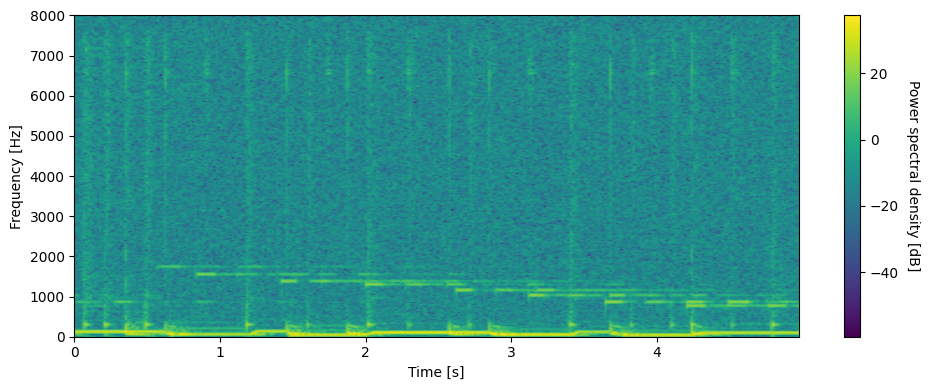

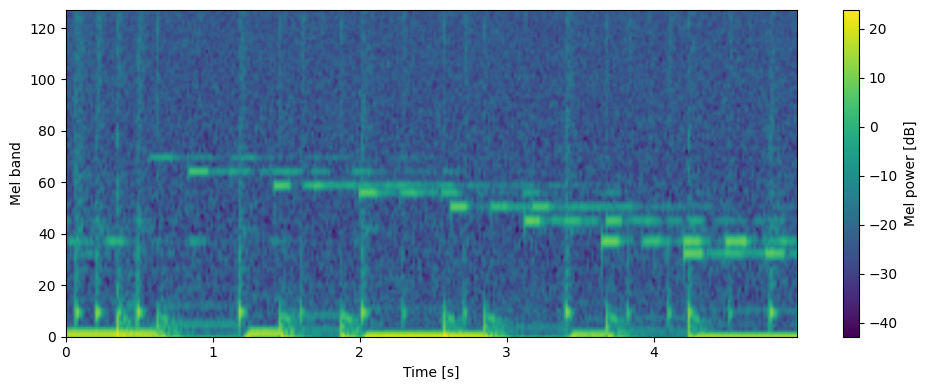

In [38]:
# YOUR CODE COMES HERE ! Your task is to produce a matrix 50 x 706 with similarity measures

# Určení počtu klipů jak  validační sady tak i u známé sady:
def sound_clips(folder):
    return sum(len(files) for _, _, files in os.walk(folder))


known_snound_clips_num = sound_clips("known")   #706
valid_snound_clips_num = sound_clips("valid")   #51
#print(known_snound_clips_num)
#print(valid_snound_clips_num)



"""
Nahlédnutí do dat - rozmezí hodnot, datový typ, tvar
Nahlédnutí jsem uskutečnil přes první známý vzorek
"""
known_Fs, known_samples = wavfile.read(f"known/{0}.wav")    #16000, #160000
print("Vzorkovací frekvence (known): ", known_Fs, "1D pole s 10ti vzorky (první known signál) (known): ", known_samples[:10])
print("Tvar dat (known): ", known_samples.shape, "Datový typ (known): ", known_samples.dtype)
known_sample_len = known_samples.shape[0]
print("Délka prvního vzroku dat (known)", known_samples.shape[0])
#print(known_samples[:10])



"""
Nahlédnutí do dat - rozmezí hodnot, datový typ, tvar
Nahlédnutí jsem uskutečnil přes první známý vzorek
"""
valid_Fs, valid_samples = wavfile.read(f"valid/{0}.wav")    #16000, #80000
print("Vzorkovací frekvence (valid): ", valid_Fs, "1D pole s 10ti vzorky (první known signál) (valid): ", valid_samples[:10])
print("Tvar dat (valid): ", valid_samples.shape, "Datový typ (valid): ", valid_samples.dtype)
valid_sample_len = valid_samples.shape[0]
print("Délka prvního vzroku dat (valid)", valid_samples.shape[0])
#print(valid_samples[:10])




# Prázdné vektory pro uložení normalizovaných dat:
valid_vec = np.zeros((valid_snound_clips_num, valid_sample_len), dtype=np.float32)
known_vec = np.zeros((known_snound_clips_num, known_sample_len), dtype=np.float32)




"""
Normalizace funcke, převední rozsahů hodnot od −32768 do +32767 na -1 do +1
"""
def int16_to_unit_closed(x):
    xf = x.astype(np.float32)
    return np.where(xf < 0, xf / 32768.0, xf / 32767.0).astype(np.float32)


def norming(folder: str, n_files: int, out_mat: np.ndarray):
    for i in range(n_files):
        _, s = wavfile.read(f"{folder}/{i}.wav")
        out_mat[i, :] = int16_to_unit_closed(s)

"""
Proces normalizování:
"""
norming("valid", valid_snound_clips_num-1, valid_vec)   # -1 bcs of 51 ???
norming("known", known_snound_clips_num, known_vec)

test_known_vec_first = known_vec[0]
print("Nanormovaných prvních 10 vzorků první skladby (known)): ", test_known_vec_first[:10])

test_valid_vec_first = valid_vec[0]
print("Nanormovaných prvních 10 vzorků první skladby (valid)): ", test_valid_vec_first[:10])









# Framing:
"""
Framing - rozřeže 1D signál a na rámce délky frame_len se skokem frame_shift
výstup - matice [počet rámců X délka rámce], každý řádek je jeden ůsek signálu připravený
k vynásobením oknem


vzorky    |----------400------------------|----------400--------------------|--------
frame 1:  [0.............................400)
frame 2:               [160.............................560)
frame 3:                              [320.............................720)

"""

def framing(a, frame_len, frame_shift=1):
    """
    from 03_spectral_2.ipynb   by profesor Černocký

    upraveno pro padding - doplňují se nuly aby vyšel plný poslední rámec
    """
    a = np.asarray(a)
    L = a.shape[0]

    if L < frame_len:
        pad_amount = frame_len - L
    else:
        rem = (L - frame_len) % frame_shift
        pad_amount = 0 if rem == 0 else (frame_shift - rem)
    if pad_amount > 0:
        a = np.pad(a, (0, pad_amount), mode='constant', constant_values=0.0)
        L = a.shape[0]

    a = np.ascontiguousarray(a)

    if L < frame_len:
        return np.empty((0, frame_len), dtype=a.dtype)

    n_frames = 1 + (L - frame_len) // frame_shift
    shape   = (n_frames, frame_len) + a.shape[1:]
    strides = (a.strides[0]*frame_shift, a.strides[0]) + a.strides[1:]
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides)




from scipy.signal.windows import hann, hamming, blackmanharris, kaiser

def spectrogram(x, window, noverlap=None, nfft=None):
    """
    from 03_spectral_2.ipynb   by profesor Černocký
    """
    if np.isscalar(window):

        """
        Okenní funkce:
        """
        window = np.hamming(int(window))
        #window = np.hanning(int(window))
        #window = kaiser(int(window), beta=8.6)
        #window = blackmanharris(int(window))


    if noverlap is None:
        noverlap = window.size // 2
    if nfft is None:
        nfft = window.size

    hop = window.size - noverlap
    Xfrm = framing(x, window.size, hop)

    W = window[None, :]
    Xfull = fft(Xfrm * W, n=nfft, axis=1)
    X = Xfull[:, : nfft//2 + 1]

    return X


def show_spectrogram(X, fs, nfft, frame_shift):
    """
    from 03_spectral_2.ipynb   by profesor Černocký
    """
    # osy
    f = np.arange(0, nfft//2 + 1) * fs / nfft
    t = np.arange(0, X.shape[0]) * frame_shift / fs

    # výpočet logaritmického výkonového spektra
    sgr_log = 10 * np.log10(np.real(np.conj(X.T) * X.T) + 1e-20)

    # zobrazení
    plt.figure(figsize=(10,4))
    plt.pcolormesh(t, f, sgr_log, shading='gouraud', cmap="viridis")
    plt.xlabel('Time [s]')
    plt.ylabel('Frequency [Hz]')
    cbar = plt.colorbar()
    cbar.set_label('Power spectral density [dB]', rotation=270, labelpad=15)
    plt.tight_layout()
    plt.show()



N = 512          #délka okna/rámce
Nfft = 1024          #velikost FFT, ≥ N
overlap = 256      #překryv rámců ve vzorcích
hop = N - overlap   #posun (frame shift) mezi začátky rámců

"""
N = 400
Nfft = 512
overlap = 256
hop = N - overlap
"""

"""
N = 640          #délka okna/rámce
Nfft = 1024          #velikost FFT, ≥ N
overlap = 320      #překryv rámců ve vzorcích
hop = N - overlap   #posun (frame shift) mezi začátky rámců
"""





X = spectrogram(valid_vec[0], N, overlap, Nfft)
show_spectrogram (X, valid_Fs, Nfft, hop)




# After scaling still same, just check
display(Audio(valid_vec[0], rate=valid_Fs))
display(Audio(f"valid/{0}.wav", rate=valid_Fs))





#########################################################################################
def mel_db(X, fs, nfft, n_mels=64, fmin=100, fmax=6000, eps=1e-10):
    S = (np.abs(X)**2).T                                                             # (bins × frames)
    H = librosa.filters.mel(sr=fs, n_fft=nfft, n_mels=n_mels, fmin=fmin, fmax=fmax)  # (mels × bins)
    return 10*np.log10(H @ S + eps)


M = mel_db(X, fs=valid_Fs, nfft=Nfft, n_mels=128, fmin=100, fmax=6000)

t = np.arange(M.shape[1]) * (hop / valid_Fs)
y = np.arange(M.shape[0])
plt.figure(figsize=(10,4))
plt.pcolormesh(t, y, M, shading='gouraud')
plt.xlabel('Time [s]')
plt.ylabel('Mel band')
plt.colorbar(label='Mel power [dB]')
plt.tight_layout()
#########################################################################################


n_mels = 96
fmin, fmax = 80, 1400


##########################################################################################
def clip_to_embedding(x):

    X = spectrogram(x, np.hanning(N), overlap, Nfft)   # komplexní STFT (frames × bins)
    M = mel_db(X, fs=Fs, nfft=Nfft, n_mels=n_mels, fmin=fmin, fmax=fmax)  # (mels × frames), dB
    emb = M.mean(axis=1)  # průměr přes čas → (mels,)
    return emb


known_emb = np.vstack([clip_to_embedding(known_vec[j]) for j in range(known_vec.shape[0])])  # shape (706, n_mels)
known_norm = np.linalg.norm(known_emb, axis=1, keepdims=True) + 1e-12  # (706,1)

##########################################################################################




N_valid = 50

def compute_similarity_matrix(N_valid, N_known):

  similarities = np.random.uniform( 0, 1, (N_valid, N_known))  #Vytvoří matici náhodných čísel v [0,1], bude přepsána v cyklu

  for i in range(N_valid):

      """
      Pro každý valdi klip se zavolá funkce clip_to_embedding()
      Spočítá se délka vektoru
      Vypočítat podobnost:
        - known_emb @ v   = vektor 706 skalárních součinů (valid vs každá known)
        - dělení normami  = převod na kosinovou podobnost, nezávislou na celkové hlasitosti
      Zapsání do podobnostní matice na odpovídající pozici
      """
      v = clip_to_embedding(valid_vec[i])
      vnorm = np.linalg.norm(v) + 1e-12
      sims = (known_emb @ v) / (known_norm.ravel() * vnorm)
      similarities[i, :] = sims

  return similarities




In [39]:
# evaluation - the function produces Top-1 and Top-5 accuracy on validation data
def eval(scores, key):
  indices = np.flip(np.argsort(scores), axis=-1) # we want highest to lowest ...
  #print(scores[0,key[0]], key[0], indices)
  top1acc = np.sum(key == indices[:,0]) / indices.shape[0]
  top5acc = 0
  for ii in range(5):
    top5acc += np.sum(key == indices[:,ii])
  top5acc /=  indices.shape[0]
  return top1acc, top5acc

key = np.loadtxt("valid/key.txt", delimiter = ',', usecols=(1), dtype ='int')

In [40]:
# here comes the computation and evaluation on validation data ...
scores_matrix = compute_similarity_matrix(N_valid, N_known)
#print (key)
top1, top5 = eval(scores_matrix, key)
print("Top 1 accuracy ", top1 * 100, "%, Top 5 accuracy ", top5 * 100, "%" )

Top 1 accuracy  98.0 %, Top 5 accuracy  98.0 %


In [42]:
# NOW on YOUR DATA ! Your task is to produce a matrix 50 x 706 with similarity measures

# load your data
N_eval = 50; duration_eval = 5; no_samples_eval = Fs * duration_eval
eval_signals=np.zeros([N_eval, no_samples_eval]); load_data(eval_signals, login, N_eval, no_samples_eval)
#display(Audio(valid_signals[45], rate=Fs))



# YOUR CODE COMES HERE ! Your task is to produce a matrix 50 x 706 with similarity measures

#převod surových vzorků na float32:
eval_vec = np.zeros((N_eval, no_samples_eval), dtype=np.float32)

#Normování na -1 do 1:
norming(login, N_eval, eval_vec)

#pro každý z 50 eval klipů spočítá embedding
eval_emb  = np.vstack([clip_to_embedding(eval_vec[i]) for i in range(N_eval)]).astype(np.float32)

"""
délka vektoru
výpočet podobnosti
(stejně jako v compute_similarity_matrix())
"""
eval_norm = np.linalg.norm(eval_emb, axis=1, keepdims=True) + 1e-12
scores_eval = (eval_emb @ known_emb.T) / (eval_norm * known_norm.T)


# Kontrola
print("scores_eval shape:", scores_eval.shape)      # tvar matice
print(scores_eval[:2, :5])                          # pro kontrolu

# export
np.savetxt("eval.txt", scores_eval)

# to download it in Google Colab click on the folder icon in the left column, find eval.txt and download it as usually.

scores_eval shape: (50, 706)
[[0.75925302 0.90428079 0.82986288 0.84181229 0.56174512]
 [0.61130016 0.61941457 0.65904283 0.67778689 0.45244501]]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Nová sekce